# Implementation of Logistics Auditor

# Story 1:
## Import necessary libraries and load the datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Loading datasets
orders =pd.read_csv('olist_orders_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')




## Show info on all tables

In [2]:
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [3]:
reviews.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [4]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [5]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


## Joining the tables(orders, reviews and customers)

In [6]:
# Join reviews onto orders using order_id, use a left join to keep all orders even those without reviews
df = orders.merge(reviews[['order_id','review_score' ]], on = 'order_id', how = 'left')


# Join customers onto thhe df above using customer_id
df = df.merge(customers[['customer_id','customer_state', 'customer_city']], on ='customer_id', how='left')

# check for duplicates
print('Orders in the original file :', len(orders))
print('Rows in merged dataframe:', len(df))

Orders in the original file : 99441
Rows in merged dataframe: 99992


In [7]:
# check for duplicates on orders
print('Unique order ids in original file:', orders['order_id'].nunique())
print('Unique order ids in merged dataframe:', df['order_id'].nunique())

Unique order ids in original file: 99441
Unique order ids in merged dataframe: 99441


In [8]:
# check if order_id has multiple reviews
review_counts = df.groupby('order_id')['review_score'].count()
print('Orders with multiple reviews:', (review_counts > 1).sum())

Orders with multiple reviews: 547


### The merged table has higher rows compared to the order table, this comes becuase some `order_id's` have multiple reviews

In [9]:
# fix it  by deduplicating reviews first
reviews_deduped = reviews.sort_values('review_answer_timestamp').drop_duplicates(subset='order_id',keep='last')
df = orders.merge(reviews_deduped[['order_id','review_score' ]], on = 'order_id', how = 'left')
df = df.merge(customers[['customer_id','customer_state', 'customer_city']], on ='customer_id', how='left')

print(f'Length of merged dataframe(should match with orders) the legth of merged is: {len(df)} and the length of original is {len(orders)}')

Length of merged dataframe(should match with orders) the legth of merged is: 99441 and the length of original is 99441


In [10]:
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,4.0,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,4.0,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,5.0,GO,vianopolis
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,5.0,RN,sao goncalo do amarante
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,5.0,SP,santo andre
...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,5.0,SP,sao jose dos campos
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,4.0,SP,praia grande
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,5.0,BA,nova vicosa
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,2.0,RJ,japuiba


# Story 2: The "Real" Delay Calculator

In [11]:
df.columns


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'review_score', 'customer_state', 'customer_city'],
      dtype='object')

In [12]:
# check for the datatype of the order_estimated_delivery_date and order_delivered_customer_date
print(f'Estimated date dtype: {df['order_estimated_delivery_date'].dtype}, Delivery date dtype:{df['order_delivered_customer_date']}')

Estimated date dtype: object, Delivery date dtype:0        2017-10-10 21:25:13
1        2018-08-07 15:27:45
2        2018-08-17 18:06:29
3        2017-12-02 00:28:42
4        2018-02-16 18:17:02
                ...         
99436    2017-03-17 15:08:01
99437    2018-02-28 17:37:56
99438    2017-09-21 11:24:17
99439    2018-01-25 23:32:54
99440    2018-03-16 13:08:30
Name: order_delivered_customer_date, Length: 99441, dtype: object


In [13]:
# convert date columns from obj to dattime
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])


print(f'Estimated date dtype: {df['order_estimated_delivery_date'].dtype}, Delivery date dtype:{df['order_delivered_customer_date']}')

Estimated date dtype: datetime64[ns], Delivery date dtype:0       2017-10-10 21:25:13
1       2018-08-07 15:27:45
2       2018-08-17 18:06:29
3       2017-12-02 00:28:42
4       2018-02-16 18:17:02
                ...        
99436   2017-03-17 15:08:01
99437   2018-02-28 17:37:56
99438   2017-09-21 11:24:17
99439   2018-01-25 23:32:54
99440   2018-03-16 13:08:30
Name: order_delivered_customer_date, Length: 99441, dtype: datetime64[ns]


In [14]:
# check for unique statuses, filter out the rest and remain with delivered

df['order_status'].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [15]:
# only consider delivered and drop the others
delivered_df = df[df['order_status']=='delivered'].copy()
delivered_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,4.0,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,4.0,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,5.0,GO,vianopolis
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,5.0,RN,sao goncalo do amarante
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,5.0,SP,santo andre
...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,5.0,SP,sao jose dos campos
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,4.0,SP,praia grande
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,5.0,BA,nova vicosa
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2.0,RJ,japuiba


In [16]:
# calculate the Days_Difference
delivered_df['Days_Difference'] = (delivered_df['order_estimated_delivery_date'] - delivered_df['order_delivered_customer_date']).dt.days
print(f"Number of missing values in Days_Difference: {delivered_df['Days_Difference'].isna().sum()}")

Number of missing values in Days_Difference: 8


In [17]:
# classify each order
def classify_delivery(days):
    if days >=0:
        return 'On Time'
    elif days >= -5:
        return 'Late'
    else:
        return 'Super Late'


delivered_df['delivery_status'] = delivered_df['Days_Difference'].apply(classify_delivery)

delivered_df['delivery_status'].value_counts()
print(delivered_df['delivery_status'].value_counts(normalize=True).mul(100).round(1))

delivery_status
On Time       91.9
Super Late     4.4
Late           3.7
Name: proportion, dtype: float64


# Story 3: The Geographic HeatMap

## Calculate % of late orders per state (late and superlate)

In [18]:
delivered_df['is_late'] = delivered_df['delivery_status'].isin(['Late','Super Late'])

state_stats = delivered_df.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum')
).reset_index()

state_stats['pct_late'] = (state_stats['late_orders']/state_stats['total_orders']*100).round(1)
state_stats = state_stats.sort_values('pct_late',ascending=False)
state_stats
state_stats.to_csv('state_stats.csv')

## Visualize as a bar chart

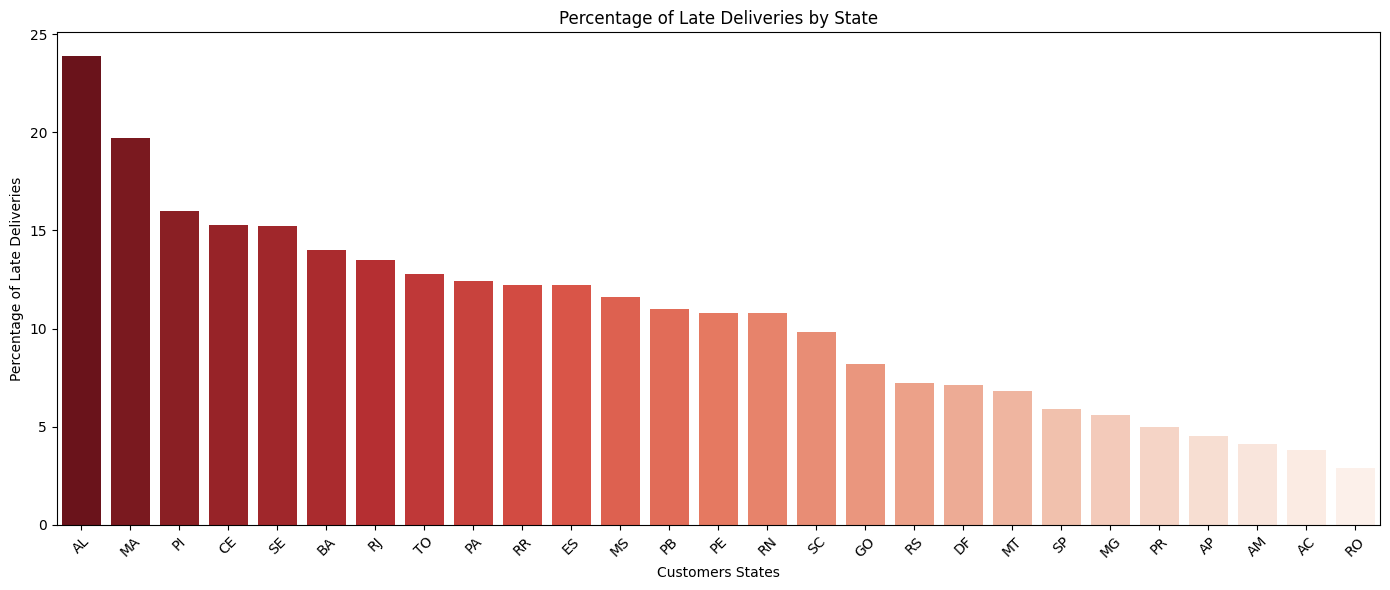

In [19]:
plt.figure(figsize=(14,6))
sns.barplot(data=state_stats, x='customer_state', y='pct_late',palette='Reds_r',hue='customer_state')
plt.title('Percentage of Late Deliveries by State')
plt.xlabel('Customers States')
plt.ylabel('Percentage of Late Deliveries')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight from the graph** AL(23.9%),MA(19.7%),PI(16.0%) and CE(15.3%) all northern states have the worst late rates. This suggests Northern Brazil, not the Amazon is the most underserved region. The low rate in AM/AP is misleading as these states have very few orders(145 and 67 respectively), suggesting customers there may not even trust OList enough to order frequently.

# Story 4: The Sentiment Correlation

## Average review score by delivery status

In [20]:
sentiment = delivered_df.groupby('delivery_status')['review_score'].mean().reset_index()
sentiment.columns = ['Delivery Status', 'Avg Review Score']
sentiment
sentiment.to_csv('sentiment.csv')

## Bar chart review score vs delivery status


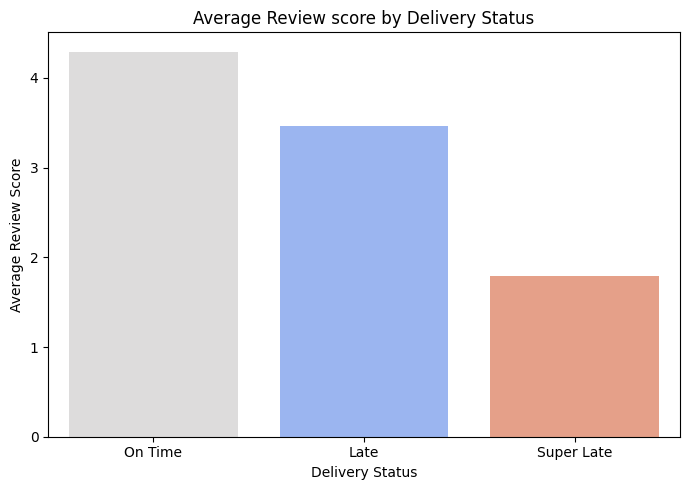

In [21]:
plt.figure(figsize=(7,5))
order=['On Time','Late','Super Late']
sns.barplot(data=sentiment, x = 'Delivery Status', y='Avg Review Score',order=order,palette='coolwarm',hue='Delivery Status')
plt.title('Average Review score by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')
plt.tight_layout()
plt.show()


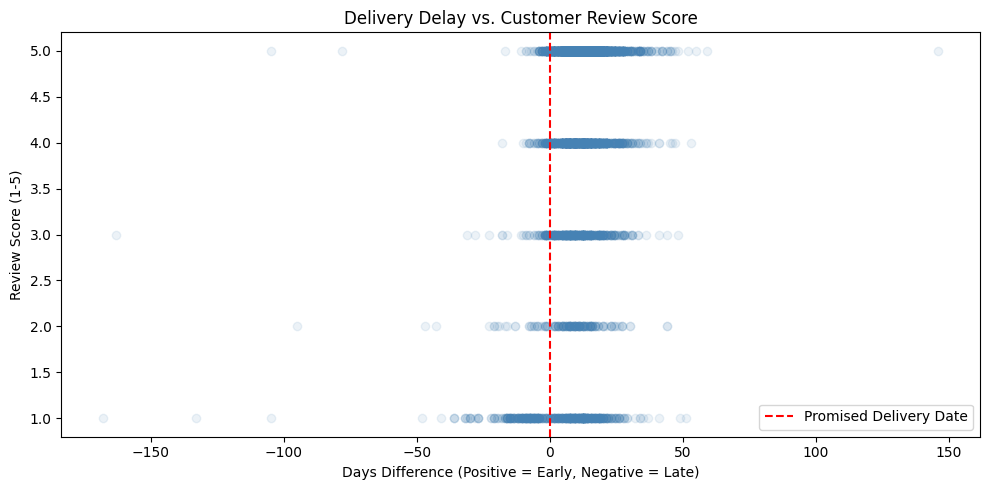

In [22]:
# scatterplot
plt.figure(figsize=(10, 5))
sample = delivered_df.sample(5000, random_state=42)
plt.scatter(sample['Days_Difference'], sample['review_score'], alpha=0.1, color='steelblue')


plt.axvline(0, color='red', linestyle='--', label='Promised Delivery Date')
plt.xlabel('Days Difference (Positive = Early, Negative = Late)')
plt.ylabel('Review Score (1-5)')
plt.title('Delivery Delay vs. Customer Review Score')
plt.legend()
plt.tight_layout()
plt.show()

# Bonus challenge

In [23]:
translations = pd.read_csv('product_category_name_translation.csv')
# join products with translation
products_translated = products.merge(translations, on ='product_category_name', how='left')

# Load order items and join with the translated products to get the category names in english
order_items = pd.read_csv('olist_order_items_dataset.csv')
order_items = order_items.merge(
    products_translated[['product_id','product_category_name_english']],
    on='product_id',
    how='left'
)
# Now join to the delivered df to get the category names for each order
delivered_df = delivered_df.merge(
    order_items[['order_id','product_category_name_english']].drop_duplicates('order_id'),
    on = 'order_id',how='left'
)

# see which categories have the worst late rates by grouping by category and calculating the percentage of late deliveries for each category
cat_stats = delivered_df.groupby('product_category_name_english').agg(
    total=('order_id', 'count'),
    late=('is_late','sum')
).reset_index()

cat_stats['pct_late'] = (cat_stats['late']/cat_stats['total']*100).round(1)
cat_stats = cat_stats[cat_stats['total']>100]
cat_stats= cat_stats.sort_values('pct_late',ascending=False).head(20)
cat_stats

,product_category_name_english,total,late,pct_late
4,audio,344,45,13.1
33,fashion_underwear_beach,117,15,12.8
10,books_technical,255,28,11.0
47,home_confort,370,38,10.3
36,food,435,44,10.1
26,electronics,2507,247,9.9
12,christmas_supplies,125,12,9.6
6,baby,2763,258,9.3
17,construction_tools_construction,728,67,9.2
57,office_furniture,1246,115,9.2


# The 'Candidates's choice': Show how the percentage of late deliveries has changed month by month
This tells the CEO 'is the problem getting worse or has it always been like this?'

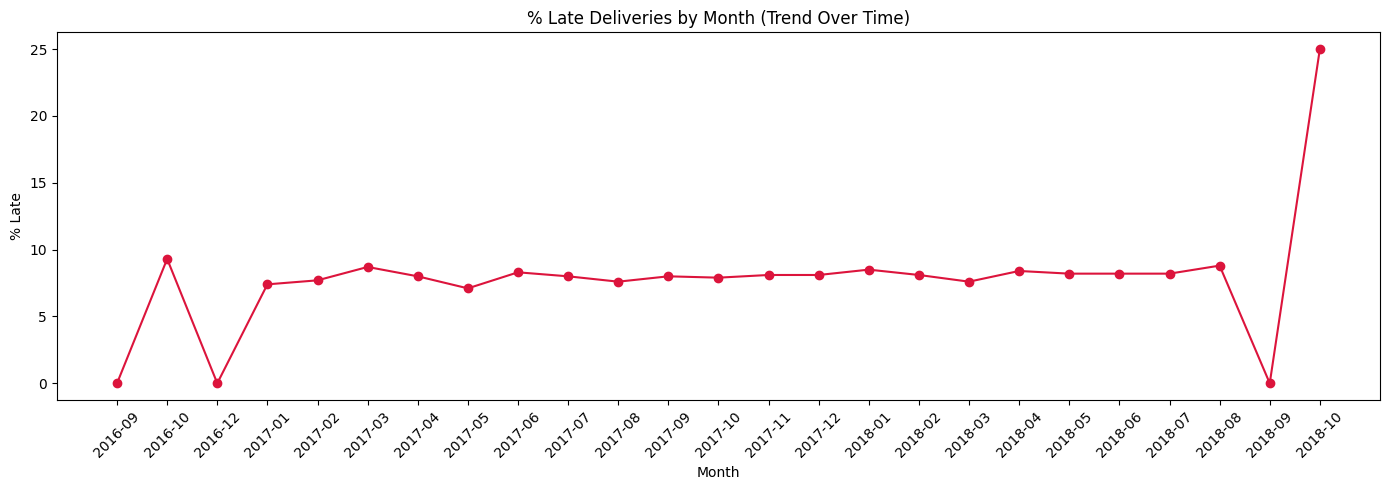

In [24]:
delivered_df['order_purchase_timestamp']=pd.to_datetime(df.loc[delivered_df.index,'order_purchase_timestamp'])
delivered_df['purchase_month']= delivered_df['order_purchase_timestamp'].dt.to_period('M')

monthly = delivered_df.groupby('purchase_month').agg(
    total=('order_id','count'),
    late=('is_late','sum')
).reset_index()
monthly['pct_late']=(monthly['late']/monthly['total']*100).round(1)
monthly['purchase_month']=monthly['purchase_month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly['purchase_month'], monthly['pct_late'], marker='o', color='crimson')
plt.xticks(rotation=45)
plt.title('% Late Deliveries by Month (Trend Over Time)')
plt.xlabel('Month')
plt.ylabel('% Late')
plt.tight_layout()
plt.savefig('monthly_late_trend.png', dpi=150)
plt.show()